In [ ]:
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
import matplotlib.font_manager as fm

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False  

In [8]:
us = pd.read_csv('../data/processed/user_summary.csv')
print('체중 기록 있는 사용자:', (us['WeightLogCount'] > 0).sum(), '/', len(us))

체중 기록 있는 사용자: 13 / 35


In [9]:
logged = us[us['WeightLogCount'] > 0]
not_logged = us[us['WeightLogCount'] == 0]

print(f'체중기록 O: n={len(logged)}, 평균걸음수={logged["AvgSteps"].mean():.0f}')
print(f'체중기록 X: n={len(not_logged)}, 평균걸음수={not_logged["AvgSteps"].mean():.0f}')

t, p = stats.ttest_ind(logged['AvgSteps'].dropna(), not_logged['AvgSteps'].dropna(), equal_var=False)
print(f't={t:.2f}, p={p:.4f}', '(유의함)' if p < 0.05 else '(유의하지 않음)')

체중기록 O: n=13, 평균걸음수=7966
체중기록 X: n=22, 평균걸음수=7209
t=0.58, p=0.5659 (유의하지 않음)


체중기록 빈도 ↔ 평균 걸음수 상관계수: 0.579


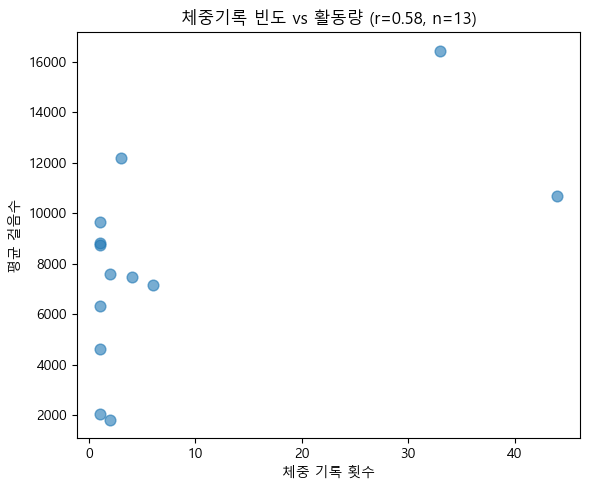

In [10]:
r = logged['WeightLogCount'].corr(logged['AvgSteps'])
print('체중기록 빈도 ↔ 평균 걸음수 상관계수:', round(r, 3))

fig, ax = plt.subplots(figsize=(6,5))
ax.scatter(logged['WeightLogCount'], logged['AvgSteps'], alpha=0.6, s=60)
ax.set_xlabel('체중 기록 횟수'); ax.set_ylabel('평균 걸음수')
ax.set_title(f'체중기록 빈도 vs 활동량 (r={r:.2f}, n={len(logged)})')
plt.tight_layout()
plt.savefig('../outputs/figures/06_weight_activity.png', dpi=130)
plt.show()

In [6]:
# 이상치 제외 후 재계산
without_outliers = logged[logged['WeightLogCount'] < 20]
r2 = without_outliers['WeightLogCount'].corr(without_outliers['AvgSteps'])
print(f'이상치(기록 20회 이상) 제외 후 상관계수: {r2:.3f} (n={len(without_outliers)})')

이상치(기록 20회 이상) 제외 후 상관계수: 0.167 (n=11)
